# 07. Off-Policy Evaluation

Off-policy evaluation (OPE) is the problem of estimating how a new decision policy would perform using data collected under an older policy.

This is one of the most industry-relevant uses of causal inference. Many companies have logs from recommenders, marketing systems, pricing engines, support-routing tools, ranking systems, sales playbooks, and human decision processes. A new policy may look promising, but deploying it directly can be expensive or risky. OPE asks:

> Can we estimate the value of the new policy before exposing customers, users, patients, sellers, or accounts to it?

The answer is "sometimes." OPE can be very powerful when the logging policy is known, stochastic, and has enough overlap with the target policy. It can be dangerously misleading when those conditions fail.

## Learning Goals

By the end of this notebook, you should be able to:

- Define logging policies, target policies, contextual bandit feedback, and policy value.
- Explain why naive offline evaluation is biased under partial feedback.
- Implement direct method, inverse propensity scoring, self-normalized IPS, clipped IPS, and doubly robust OPE.
- Diagnose support and overlap problems through importance weights.
- Compare estimator bias and variance against simulation truth.
- Explain why logged propensities are a production requirement for reliable OPE.
- Translate OPE results into a cautious industry recommendation.

### Dataset and Experiment Setup

This notebook simulates logged interventions from an existing operational policy. The unit is an account or case. For each unit, the data includes context, the action actually taken, the logging propensity, and the observed reward. Actions might represent different support levels, sales plays, retention offers, or escalation paths. The goal is to evaluate a new policy using data collected under an old policy.

This setting must be simulated because off-policy evaluation needs the true value of candidate policies for teaching. In real logs, we observe only the reward for the action that was actually taken. The counterfactual reward under a different action is hidden. The simulation includes nonuniform action assignment, propensities, reward heterogeneity, and limited support so IPS, self-normalized IPS, doubly robust estimators, and effective sample size diagnostics can be interpreted against known truth. That makes the example closer to production decision systems than a balanced randomized comparison.


In [1]:
import warnings

import graphviz
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.base import clone
from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor
from sklearn.metrics import log_loss, mean_squared_error
from sklearn.model_selection import KFold, train_test_split

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.float_format", "{:.3f}".format)

In [2]:
# Define reusable helpers so the later analytical cells stay focused on the causal argument.
ACTION_LABELS = {
    0: "No action",
    1: "Email education",
    2: "Discount offer",
    3: "Human success call",
}
N_ACTIONS = len(ACTION_LABELS)


def sigmoid(x):
    """Compute sigmoid for the off policy evaluation example.
    
    Inputs:
    - `x`: logit-scale numeric input converted into a probability.
    Returns: a NumPy array or scalar of logistic probabilities."""
    return 1 / (1 + np.exp(-x))


def row_softmax(utilities):
    """Compute row softmax for the off policy evaluation example.
    
    Inputs:
    - `utilities`: row-wise action utility scores before softmax normalization.
    Returns: one probability vector per row of the score matrix."""
    shifted = utilities - utilities.max(axis=1, keepdims=True)
    exp_u = np.exp(shifted)
    return exp_u / exp_u.sum(axis=1, keepdims=True)


def one_hot(actions, n_actions=N_ACTIONS):
    """Compute one hot for the off policy evaluation example.
    
    Inputs:
    - `actions`: integer action labels observed or assigned in the policy example.
    - `n_actions`: number of possible actions in the off-policy evaluation action set.
    Returns: a binary indicator matrix for the supplied action labels."""
    mat = np.zeros((len(actions), n_actions))
    mat[np.arange(len(actions)), np.asarray(actions, dtype=int)] = 1.0
    return mat


def make_dag(edges, title=None, node_colors=None, rankdir="LR"):
    """Construct the dag object.
    
    Inputs:
    - `edges`: directed or undirected graph edges represented as node pairs.
    - `title`: plot or graph title displayed above the figure.
    - `node_colors`: optional mapping from graph nodes to fill colors.
    - `rankdir`: Graphviz layout direction, such as left-to-right or top-to-bottom.
    Returns: a Graphviz diagram for the causal structure in the section."""
    graph = graphviz.Digraph(format="svg")
    graph.attr(rankdir=rankdir, bgcolor="white", pad="0.2")
    graph.attr("node", shape="box", style="rounded,filled", color="#334155", fontname="Helvetica")
    graph.attr("edge", color="#475569", arrowsize="0.8")

    node_colors = node_colors or {}
    nodes = sorted({node for edge in edges for node in edge[:2]})
    for node in nodes:
        graph.node(node, fillcolor=node_colors.get(node, "#eef2ff"))

    for edge in edges:
        if len(edge) == 2:
            graph.edge(edge[0], edge[1])
        else:
            graph.edge(edge[0], edge[1], label=edge[2])

    if title:
        graph.attr(label=title, labelloc="t", fontsize="18", fontname="Helvetica-Bold")
    return graph


def effective_sample_size(weights):
    """Compute effective sample size for the off policy evaluation example.
    
    Inputs:
    - `weights`: nonnegative weights used for weighted means, variances, or effective sample size.
    Returns: an effect-estimate summary for the causal comparison in the section."""
    weights = np.asarray(weights)
    if np.sum(weights**2) == 0:
        return 0.0
    return (np.sum(weights) ** 2) / np.sum(weights**2)

## 1. The OPE Problem

A logged decision dataset contains triples:

$$
(X_i, A_i, R_i)
$$

where:

- $X_i$ is the context available at decision time.
- $A_i$ is the action chosen by the logging policy.
- $R_i$ is the observed reward for the chosen action.

The key difficulty is partial feedback. We observe the reward for the action actually taken, but not the rewards that would have occurred under the other actions.

Let the historical logging policy be:

$$
\mu(a \mid x)
$$

and let the new target policy be:

$$
\pi(a \mid x)
$$

The policy value is:

$$
V(\pi) = E\left[\sum_{a} \pi(a \mid X)Y(a)\right]
$$

OPE estimates $V(\pi)$ using data collected under $\mu$, without deploying $\pi$.

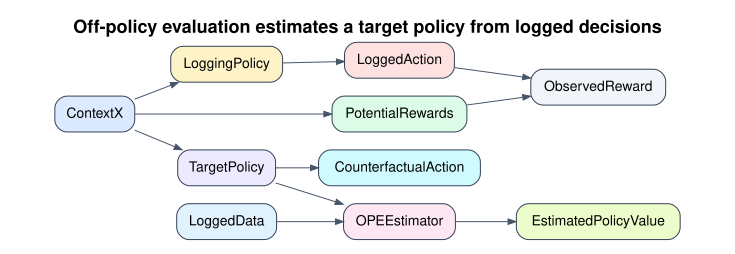

In [3]:
# Organize the calculations for this section into readable intermediate steps.
make_dag(
    edges=[
        ("ContextX", "LoggingPolicy"),
        ("LoggingPolicy", "LoggedAction"),
        ("ContextX", "PotentialRewards"),
        ("LoggedAction", "ObservedReward"),
        ("PotentialRewards", "ObservedReward"),
        ("ContextX", "TargetPolicy"),
        ("TargetPolicy", "CounterfactualAction"),
        ("LoggedData", "OPEEstimator"),
        ("TargetPolicy", "OPEEstimator"),
        ("OPEEstimator", "EstimatedPolicyValue"),
    ],
    title="Off-policy evaluation estimates a target policy from logged decisions",
    node_colors={
        "ContextX": "#dbeafe",
        "LoggingPolicy": "#fef3c7",
        "LoggedAction": "#fee2e2",
        "PotentialRewards": "#dcfce7",
        "ObservedReward": "#f1f5f9",
        "TargetPolicy": "#ede9fe",
        "CounterfactualAction": "#cffafe",
        "LoggedData": "#e0f2fe",
        "OPEEstimator": "#fce7f3",
        "EstimatedPolicyValue": "#ecfccb",
    },
)

Dudík et al. (2014) present doubly robust policy evaluation and optimization for contextual bandits. Horvitz and Thompson (1952) is the classical origin of inverse-probability weighting. Modern OPE work studies the bias-variance tradeoff among direct modeling, importance weighting, self-normalization, clipping, and doubly robust estimators (Su et al., 2019; Zhan et al., 2021; Saito & Joachims, 2022).

## 2. Identification Conditions

For the basic contextual bandit OPE estimators in this notebook, the important conditions are:

1. Consistency: the observed reward equals the potential reward for the action actually taken.
2. Conditional exchangeability: after conditioning on logged context $X$, action assignment is as good as random according to the logging policy.
3. Positivity or overlap. If the target policy may choose action $a$ at context $x$, then the logging policy must have nonzero probability of choosing that action.

$$
\pi(a \mid x) > 0 \Rightarrow \mu(a \mid x) > 0
$$

4. Correct logging probabilities: the analyst must know or accurately estimate $\mu(A_i \mid X_i)$.

OPE is not a shortcut around identification. It is a way to use randomized or conditionally randomized historical logs efficiently.

## 3. Running Example: Offline Evaluation of Account Interventions

Imagine a SaaS company deciding among four account-level interventions:

- No action.
- Send educational lifecycle email.
- Offer a limited discount.
- Assign a human customer-success call.

The company has historical logs from a stochastic decision policy. That policy used account context and deliberately kept some exploration, so every action had at least some chance of being chosen. Now the team wants to evaluate new targeting policies offline before running a live experiment.

In this simulation, we observe the true potential reward functions only because we created the data. Real OPE projects do not have that luxury; simulation truth is used here to check estimator behavior.

In [4]:
# Generate the teaching data and keep the causal quantities needed for diagnostics.
def simulate_account_intervention_logs(n=12000, seed=5707):
    """Simulate the account intervention logs data-generating process.
    
    Inputs:
    - `n`: number of simulated units or records to generate for the teaching example.
    - `seed`: integer random seed that makes the simulation or model split reproducible.
    Returns: a pandas DataFrame with generated covariates, treatment or policy variables, outcomes, and teaching diagnostics for this scenario."""
    rng = np.random.default_rng(seed)

    churn_risk = rng.beta(2.1, 2.4, n)
    product_health = rng.beta(2.5, 2.0, n)
    email_engagement = rng.beta(1.7, 2.4, n)
    price_sensitivity = rng.beta(2.0, 2.6, n)
    usage_depth = rng.normal(0, 1, n)
    log_mrr = rng.normal(4.45, 0.65, n)
    mrr_z = (log_mrr - log_mrr.mean()) / log_mrr.std()
    enterprise = rng.binomial(1, sigmoid(-0.35 + 0.9 * mrr_z + 0.45 * churn_risk), n)
    strategic = rng.binomial(1, sigmoid(-1.4 + 1.0 * enterprise + 0.55 * mrr_z), n)
    onboarding_gap = rng.beta(1.8, 3.0, n)
    support_load = rng.poisson(np.clip(0.3 + 3.2 * churn_risk - 0.8 * product_health + 0.7 * enterprise, 0.05, None))
    region_west = rng.binomial(1, 0.32, n)
    region_emea = rng.binomial(1, 0.27, n) * (1 - region_west)

    baseline = (
        58
        + 11.0 * mrr_z
        + 18.0 * product_health
        - 24.0 * churn_risk
        + 5.5 * enterprise
        + 3.0 * strategic
        + 3.2 * usage_depth
        - 1.6 * support_load
        - 7.0 * onboarding_gap
        + 2.4 * region_west
        - 1.4 * region_emea
        + 3.0 * np.sin(usage_depth)
    )

    effect_no_action = np.zeros(n)
    effect_email = (
        1.5
        + 10.0 * onboarding_gap
        + 8.0 * email_engagement * (1 - product_health)
        + 3.5 * (usage_depth < -0.5)
        - 2.2 * enterprise
        - 1.0 * np.maximum(support_load - 4, 0)
    )
    effect_discount = (
        -1.0
        + 19.0 * price_sensitivity
        + 8.0 * churn_risk
        - 6.0 * product_health
        - 4.5 * enterprise
        - 2.0 * strategic
    )
    effect_call = (
        -7.0
        + 23.0 * enterprise * churn_risk
        + 9.0 * strategic
        + 12.0 * onboarding_gap
        + 4.0 * (support_load <= 3)
        - 6.0 * (product_health > 0.72)
        + 2.0 * region_emea
    )

    mu = np.column_stack(
        [
            baseline + effect_no_action,
            baseline + effect_email,
            baseline + effect_discount,
            baseline + effect_call,
        ]
    )

    logging_utilities = np.column_stack(
        [
            0.45 + 0.75 * product_health - 0.80 * churn_risk,
            0.10 + 1.35 * onboarding_gap + 0.75 * email_engagement - 0.30 * enterprise,
            -0.15 + 1.55 * price_sensitivity + 0.85 * churn_risk - 0.40 * strategic,
            -0.75 + 1.15 * enterprise + 0.85 * strategic + 1.15 * churn_risk + 0.18 * support_load,
        ]
    )
    logging_probs = row_softmax(logging_utilities)
    exploration = 0.08
    logging_probs = (1 - exploration) * logging_probs + exploration / N_ACTIONS

    actions = np.array([rng.choice(N_ACTIONS, p=probs) for probs in logging_probs])
    reward = mu[np.arange(n), actions] + rng.normal(0, 7.0, n)

    df = pd.DataFrame(
        {
            "account_id": np.arange(1, n + 1),
            "churn_risk": churn_risk,
            "product_health": product_health,
            "email_engagement": email_engagement,
            "price_sensitivity": price_sensitivity,
            "usage_depth": usage_depth,
            "log_mrr": log_mrr,
            "mrr_z": mrr_z,
            "enterprise": enterprise,
            "strategic": strategic,
            "onboarding_gap": onboarding_gap,
            "support_load": support_load,
            "region_west": region_west,
            "region_emea": region_emea,
            "action": actions,
            "action_label": [ACTION_LABELS[a] for a in actions],
            "reward": reward,
            "logging_prob_chosen": logging_probs[np.arange(n), actions],
        }
    )
    for action_id, label in ACTION_LABELS.items():
        safe_label = label.lower().replace(" ", "_")
        df[f"mu_{action_id}"] = mu[:, action_id]
        df[f"logging_prob_{action_id}"] = logging_probs[:, action_id]
        df[f"incremental_vs_no_action_{safe_label}"] = mu[:, action_id] - mu[:, 0]

    return df


df = simulate_account_intervention_logs()
df.head()

,account_id,churn_risk,product_health,email_engagement,price_sensitivity,usage_depth,log_mrr,mrr_z,enterprise,strategic,...,incremental_vs_no_action_no_action,mu_1,logging_prob_1,incremental_vs_no_action_email_education,mu_2,logging_prob_2,incremental_vs_no_action_discount_offer,mu_3,logging_prob_3,incremental_vs_no_action_human_success_call
0,1,0.420,0.692,0.537,0.129,-0.286,5.600,1.785,0,0,...,0.000,81.913,0.420,8.268,74.307,0.194,0.662,77.178,0.147,3.533
1,2,0.390,0.796,0.509,0.294,0.424,4.775,0.512,0,0,...,0.000,72.310,0.282,3.645,71.603,0.276,2.938,61.241,0.140,-7.424
2,3,0.780,0.325,0.352,0.485,-0.314,4.385,-0.090,0,0,...,0.000,37.010,0.193,3.767,45.753,0.375,12.509,27.883,0.305,-5.360
3,4,0.313,0.369,0.850,0.663,0.553,4.939,0.765,1,1,...,0.000,76.399,0.210,8.984,72.796,0.145,5.381,89.090,0.529,21.675
4,5,0.009,0.611,0.781,0.194,-1.266,3.769,-1.039,0,0,...,0.000,61.331,0.423,10.964,49.460,0.167,-0.906,51.606,0.080,1.240


At this point, ask what the result lets us defend. Logged data can evaluate a new policy only where the old policy created enough support.

In [5]:
# Assemble the summary table used to interpret the causal comparison.
feature_cols = [
    "churn_risk",
    "product_health",
    "email_engagement",
    "price_sensitivity",
    "usage_depth",
    "mrr_z",
    "enterprise",
    "strategic",
    "onboarding_gap",
    "support_load",
    "region_west",
    "region_emea",
]
mu_cols = [f"mu_{a}" for a in range(N_ACTIONS)]
logging_prob_cols = [f"logging_prob_{a}" for a in range(N_ACTIONS)]

summary = pd.DataFrame(
    {
        "quantity": [
            "Logged decisions",
            "Average observed reward",
            "Average chosen-action propensity",
            "Minimum chosen-action propensity",
            "Action with highest average true reward",
            "Average value under logging policy",
        ],
        "value": [
            len(df),
            df["reward"].mean(),
            df["logging_prob_chosen"].mean(),
            df["logging_prob_chosen"].min(),
            ACTION_LABELS[np.argmax(df[mu_cols].mean().to_numpy())],
            np.mean((df[logging_prob_cols].to_numpy() * df[mu_cols].to_numpy()).sum(axis=1)),
        ],
    }
)
display(summary)

,quantity,value
0,Logged decisions,12000
1,Average observed reward,62.761
2,Average chosen-action propensity,0.316
3,Minimum chosen-action propensity,0.045
4,Action with highest average true reward,Human success call
5,Average value under logging policy,62.824


In an applied workflow, the main point is direct. The behavior policy is part of the evidence, so weights and support deserve as much attention as the value estimate.

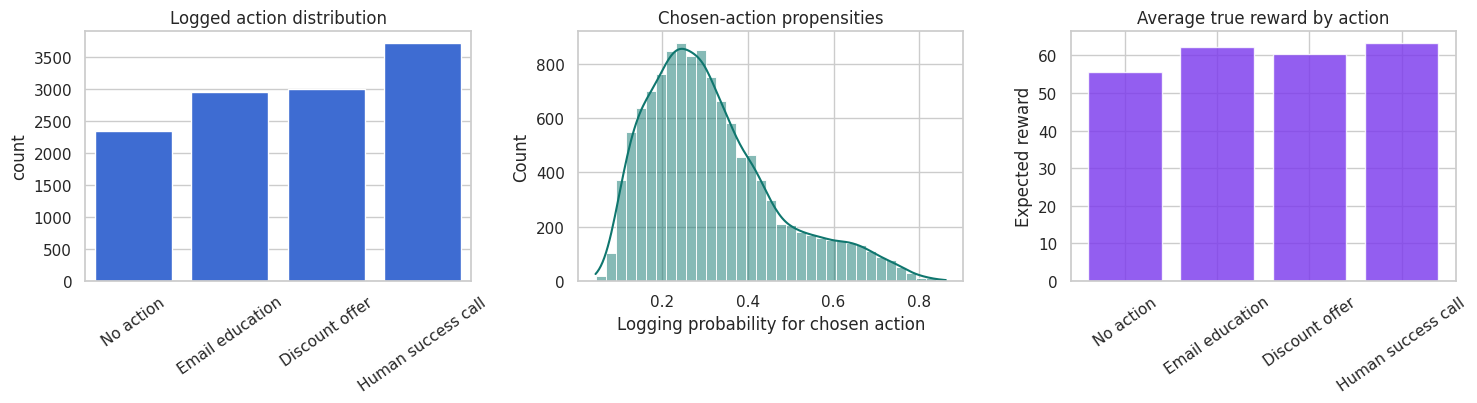

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

sns.countplot(data=df, x="action_label", order=list(ACTION_LABELS.values()), color="#2563eb", ax=axes[0])
axes[0].set_title("Logged action distribution")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=35)

sns.histplot(df["logging_prob_chosen"], bins=35, kde=True, color="#0f766e", ax=axes[1])
axes[1].set_title("Chosen-action propensities")
axes[1].set_xlabel("Logging probability for chosen action")

true_action_means = df[mu_cols].mean().rename(index={f"mu_{a}": ACTION_LABELS[a] for a in range(N_ACTIONS)})
axes[2].bar(true_action_means.index, true_action_means.values, color="#7c3aed", alpha=0.82)
axes[2].set_title("Average true reward by action")
axes[2].set_ylabel("Expected reward")
axes[2].tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()

This setup is a contextual bandit:

- The system sees context.
- It chooses one action.
- It observes only that action's reward.
- The rewards for the unchosen actions are missing.

The logging policy is stochastic and stores propensities. That is the feature that makes reliable OPE possible. If the logs only stored the chosen action and reward, we would have a much weaker evaluation problem.

## 4. Candidate Target Policies

We will evaluate several target policies:

- Logging policy: the policy that generated the data.
- Uniform random policy: a sanity-check policy.
- Business rule: a transparent hand-built rule.
- Model argmax policy: a deterministic policy that chooses the action with the highest predicted reward.
- Conservative model policy: mostly follows the model argmax but keeps 15% uniform exploration.
- Aggressive call-heavy policy: a riskier policy that uses many human calls.

The model-based policies are learned on a policy-design split. Their values are evaluated on a separate evaluation split.

In [7]:
# Define reusable helpers so the later analytical cells stay focused on the causal argument.
design_idx, eval_idx = train_test_split(
    df.index,
    test_size=0.45,
    random_state=5710,
    stratify=df["action"],
)
design = df.loc[design_idx].copy()
eval_logs = df.loc[eval_idx].copy()


def fit_action_reward_models(frame, feature_cols):
    """Fit the action reward models model or estimator.
    
    Inputs:
    - `frame`: pandas DataFrame containing the rows for this function and the causal variables named by the other arguments.
    - `feature_cols`: list of pre-treatment covariate column names used as model features or effect modifiers.
    Returns: fitted model objects or a structured result used by the estimator in this notebook."""
    models = {}
    base_model = HistGradientBoostingRegressor(
        max_iter=180,
        learning_rate=0.045,
        min_samples_leaf=45,
        l2_regularization=0.03,
        random_state=5711,
    )
    for action_id in range(N_ACTIONS):
        action_frame = frame[frame["action"] == action_id]
        model = clone(base_model)
        model.fit(action_frame[feature_cols], action_frame["reward"])
        models[action_id] = model
    return models


def predict_action_rewards(models, frame, feature_cols):
    """Generate action rewards predictions.
    
    Inputs:
    - `models`: collection of fitted action-specific or treatment-specific models.
    - `frame`: pandas DataFrame containing the rows for this function and the causal variables named by the other arguments.
    - `feature_cols`: list of pre-treatment covariate column names used as model features or effect modifiers.
    Returns: predicted effects, rewards, or outcomes for the rows passed into the function."""
    preds = np.zeros((len(frame), N_ACTIONS))
    for action_id, model in models.items():
        preds[:, action_id] = model.predict(frame[feature_cols])
    return preds


policy_design_models = fit_action_reward_models(design, feature_cols)
eval_pred_rewards_for_policy = predict_action_rewards(policy_design_models, eval_logs, feature_cols)
model_argmax_actions = eval_pred_rewards_for_policy.argmax(axis=1)


def business_rule_actions(frame):
    """Apply the interpretable business-rule policy to each account.
    
    Inputs:
    - `frame`: pandas DataFrame containing the rows for this function and the causal variables named by the other arguments.
    Returns: an integer action array assigning each row to no action, email, discount, or call."""
    action = np.zeros(len(frame), dtype=int)
    call = (frame["enterprise"].to_numpy() == 1) & (frame["churn_risk"].to_numpy() > 0.58)
    discount = (~call) & (frame["price_sensitivity"].to_numpy() > 0.67) & (frame["churn_risk"].to_numpy() > 0.42)
    email = (~call) & (~discount) & (
        (frame["onboarding_gap"].to_numpy() > 0.55) | (frame["email_engagement"].to_numpy() > 0.65)
    )
    action[email] = 1
    action[discount] = 2
    action[call] = 3
    return action


def aggressive_call_actions(frame):
    """Apply the aggressive call policy used as an off-policy benchmark.
    
    Inputs:
    - `frame`: pandas DataFrame containing the rows for this function and the causal variables named by the other arguments.
    Returns: an integer action array that escalates more accounts to the call intervention."""
    action = np.ones(len(frame), dtype=int)
    discount = frame["price_sensitivity"].to_numpy() > 0.55
    call = (frame["enterprise"].to_numpy() == 1) | (frame["churn_risk"].to_numpy() > 0.48)
    action[discount] = 2
    action[call] = 3
    return action


def conservative_probs(actions, epsilon=0.15):
    """Convert deterministic actions into an epsilon-smoothed target policy.
    
    Inputs:
    - `actions`: integer action labels observed or assigned in the policy example.
    - `epsilon`: small exploration probability used to keep every action possible under the policy.
    Returns: a probability matrix with most mass on the chosen action and small mass on alternatives."""
    return (1 - epsilon) * one_hot(actions) + epsilon / N_ACTIONS


target_policies = {
    "Logging policy": eval_logs[logging_prob_cols].to_numpy(),
    "Uniform random": np.ones((len(eval_logs), N_ACTIONS)) / N_ACTIONS,
    "Business rule": one_hot(business_rule_actions(eval_logs)),
    "Model argmax": one_hot(model_argmax_actions),
    "Conservative model": conservative_probs(model_argmax_actions, epsilon=0.15),
    "Aggressive call-heavy": one_hot(aggressive_call_actions(eval_logs)),
}

policy_action_mix = []
for policy_name, probs in target_policies.items():
    action_rates = probs.mean(axis=0)
    row = {"policy": policy_name}
    for action_id, label in ACTION_LABELS.items():
        row[label] = action_rates[action_id]
    policy_action_mix.append(row)

display(pd.DataFrame(policy_action_mix))

,policy,No action,Email education,Discount offer,Human success call
0,Logging policy,0.189,0.248,0.253,0.310
1,Uniform random,0.250,0.250,0.250,0.250
2,Business rule,0.503,0.276,0.065,0.156
3,Model argmax,0.008,0.291,0.242,0.459
4,Conservative model,0.044,0.285,0.244,0.427
5,Aggressive call-heavy,0.000,0.204,0.092,0.704


The action mix is an immediate deployment diagnostic. A policy that shifts heavily toward an expensive or operationally scarce action may have a high estimated reward but still be infeasible.

It is also an OPE diagnostic. The more different the target policy is from the logging policy, the harder offline evaluation becomes.

## 5. Ground Truth Value in Simulation

In real life, policy value is unknown. Here we can compute it because the simulation contains all potential reward means:

$$
V(\pi) =
\frac{1}{n}
\sum_{i}
\sum_{a}
\pi(a \mid X_i)\mu_a(X_i)
$$

where $\mu_a(X_i)=E[Y_i(a)\mid X_i]$.

This simulation truth lets us separate two questions:

- What does each OPE estimator say?
- How close is that estimate to the value we know from the data-generating process?

In [8]:
def true_policy_value(frame, target_probs):
    """Compute the true value of a target policy using simulated potential rewards.
    
    Inputs:
    - `frame`: pandas DataFrame containing the rows for this function and the causal variables named by the other arguments.
    - `target_probs`: target-policy action probabilities for each row in the logged dataset.
    Returns: a scalar mean reward under the target action probabilities."""
    return np.mean(np.sum(target_probs * frame[mu_cols].to_numpy(), axis=1))


truth_table = pd.DataFrame(
    [
        {
            "policy": name,
            "true_value": true_policy_value(eval_logs, probs),
            "true_gain_vs_logging": true_policy_value(eval_logs, probs)
            - true_policy_value(eval_logs, target_policies["Logging policy"]),
        }
        for name, probs in target_policies.items()
    ]
).sort_values("true_value", ascending=False)

display(truth_table)

,policy,true_value,true_gain_vs_logging
3,Model argmax,67.325,4.533
4,Conservative model,66.276,3.484
5,Aggressive call-heavy,65.291,2.499
0,Logging policy,62.792,0.000
2,Business rule,61.850,-0.942
1,Uniform random,60.333,-2.459


## 6. Why Naive Offline Evaluation Fails

A naive matched-outcome estimate keeps only rows where the logged action matches the target policy action and averages their observed rewards.

For deterministic target policies:

$$
\hat{V}_{matched} =
\frac{\sum_{i} 1\{A_i = \pi(X_i)\}R_i}
{\sum_{i} 1\{A_i = \pi(X_i)\}}
$$

This can be badly biased when the logging policy is context-dependent. The matched rows are not a random sample of all contexts. They are the contexts where the logging policy happened to take the same action as the target policy.

Proper OPE accounts for the probability of the observed action under the logging policy.

In [9]:
def deterministic_actions_from_probs(probs):
    """Convert a target-policy probability matrix into chosen actions.
    
    Inputs:
    - `probs`: row-wise action probability matrix used to choose deterministic policy actions.
    Returns: an integer array selecting the highest-probability action for each row."""
    is_deterministic = np.all((np.isclose(probs, 0) | np.isclose(probs, 1)), axis=1)
    if not np.all(is_deterministic):
        return None
    return probs.argmax(axis=1)


naive_rows = []
for policy_name, probs in target_policies.items():
    target_actions = deterministic_actions_from_probs(probs)
    if target_actions is None:
        continue
    matched = eval_logs["action"].to_numpy() == target_actions
    naive_rows.append(
        {
            "policy": policy_name,
            "matched_share": matched.mean(),
            "naive_matched_reward": eval_logs.loc[matched, "reward"].mean(),
            "true_value": true_policy_value(eval_logs, probs),
            "naive_bias": eval_logs.loc[matched, "reward"].mean() - true_policy_value(eval_logs, probs),
        }
    )

display(pd.DataFrame(naive_rows).sort_values("naive_bias"))

,policy,matched_share,naive_matched_reward,true_value,naive_bias
0,Business rule,0.323,63.967,61.850,2.117
1,Model argmax,0.402,69.657,67.325,2.332
2,Aggressive call-heavy,0.377,69.453,65.291,4.162


The matched-outcome estimator is tempting because it feels like "look at cases where we did the same thing." But if the old system took that action only for certain kinds of accounts, the matched subset does not represent the population the new policy would touch.

## 7. OPE Estimators

Let $p_i = \mu(A_i \mid X_i)$ be the logged propensity of the action actually taken.

Let $q_i = \pi(A_i \mid X_i)$ be the target policy probability of that same action.

The importance weight is:

$$
w_i = \frac{q_i}{p_i}
$$

Inverse propensity scoring estimates:

$$
\hat{V}_{IPS} =
\frac{1}{n}\sum_{i} w_i R_i
$$

Self-normalized IPS estimates:

$$
\hat{V}_{SNIPS} =
\frac{\sum_{i} w_i R_i}{\sum_{i} w_i}
$$

The direct method estimates a reward model $\hat{\mu}_a(x)$ and plugs it in:

$$
\hat{V}_{DM} =
\frac{1}{n}\sum_{i}\sum_{a} \pi(a \mid X_i)\hat{\mu}_a(X_i)
$$

The doubly robust estimator combines both:

$$
\hat{V}_{DR}
=
\frac{1}{n}\sum_{i}
\left[
\sum_{a} \pi(a \mid X_i)\hat{\mu}_a(X_i)
+
\frac{\pi(A_i \mid X_i)}{\mu(A_i \mid X_i)}
\{R_i-\hat{\mu}_{A_i}(X_i)\}
\right]
$$

DR is attractive because the reward model supplies baseline predictions while the weighted residual corrects the model using logged outcomes.

In [10]:
# Fit the models for this section and assemble the estimates used in the discussion.
def crossfit_reward_matrix(frame, feature_cols, n_splits=5, seed=5712):
    """Build cross-fitted reward matrix quantities.
    
    Inputs:
    - `frame`: pandas DataFrame containing the rows for this function and the causal variables named by the other arguments.
    - `feature_cols`: list of pre-treatment covariate column names used as model features or effect modifiers.
    - `n_splits`: number of folds used for cross-fitting so rows are predicted out of sample.
    - `seed`: integer random seed that makes the simulation or model split reproducible.
    Returns: out-of-fold predictions or scores built without using each row to predict itself."""
    n = len(frame)
    mu_hat = np.zeros((n, N_ACTIONS))
    fold_id = np.zeros(n, dtype=int)
    base_model = HistGradientBoostingRegressor(
        max_iter=180,
        learning_rate=0.045,
        min_samples_leaf=40,
        l2_regularization=0.025,
        random_state=seed,
    )

    kfold = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    for fold, (train_idx, test_idx) in enumerate(kfold.split(frame), start=1):
        train = frame.iloc[train_idx]
        test = frame.iloc[test_idx]
        for action_id in range(N_ACTIONS):
            action_train = train[train["action"] == action_id]
            model = clone(base_model)
            model.fit(action_train[feature_cols], action_train["reward"])
            mu_hat[test_idx, action_id] = model.predict(test[feature_cols])
        fold_id[test_idx] = fold
    return mu_hat, fold_id


mu_hat_eval, fold_id_eval = crossfit_reward_matrix(eval_logs, feature_cols)
eval_logs = eval_logs.copy()
eval_logs["fold"] = fold_id_eval

chosen_actions = eval_logs["action"].to_numpy()
chosen_mu_hat = mu_hat_eval[np.arange(len(eval_logs)), chosen_actions]
reward_rmse_chosen = np.sqrt(mean_squared_error(eval_logs["reward"], chosen_mu_hat))
potential_rmse = np.sqrt(mean_squared_error(eval_logs[mu_cols].to_numpy().ravel(), mu_hat_eval.ravel()))

pd.DataFrame(
    {
        "diagnostic": [
            "Out-of-fold reward RMSE on observed actions",
            "Out-of-fold reward RMSE against all simulated potential means",
        ],
        "value": [reward_rmse_chosen, potential_rmse],
    }
)

,diagnostic,value
0,Out-of-fold reward RMSE on observed actions,7.897
1,Out-of-fold reward RMSE against all simulated ...,3.663


This result should affect the next modeling or decision step. Offline policy value is credible only when the log contains comparable actions in comparable contexts.

In [11]:
# Assemble the summary table used to interpret the causal comparison.
def evaluate_ope_estimators(frame, target_probs, mu_hat, logging_probs=None, clip=12.0):
    """Evaluate the ope estimators calculation.
    
    Inputs:
    - `frame`: pandas DataFrame containing the rows for this function and the causal variables named by the other arguments.
    - `target_probs`: target-policy action probabilities for each row in the logged dataset.
    - `mu_hat`: estimated reward matrix used as the outcome model in doubly robust evaluation.
    - `logging_probs`: behavior-policy probabilities for the actions observed in the logged data.
    - `clip`: maximum importance weight used to stabilize high-variance off-policy estimates.
    Returns: policy or estimator performance summaries for the candidate decision rule."""
    if logging_probs is None:
        logging_probs = frame[logging_prob_cols].to_numpy()
    action = frame["action"].to_numpy()
    reward = frame["reward"].to_numpy()
    n = len(frame)

    p_chosen = logging_probs[np.arange(n), action]
    q_chosen = target_probs[np.arange(n), action]
    weights = q_chosen / np.clip(p_chosen, 1e-6, None)
    clipped_weights = np.minimum(weights, clip)

    dm_row = np.sum(target_probs * mu_hat, axis=1)
    residual = reward - mu_hat[np.arange(n), action]

    ips_contrib = weights * reward
    clipped_ips_contrib = clipped_weights * reward
    dr_contrib = dm_row + weights * residual
    clipped_dr_contrib = dm_row + clipped_weights * residual

    estimators = {
        "Direct method": dm_row,
        "IPS": ips_contrib,
        "Clipped IPS": clipped_ips_contrib,
        "Doubly robust": dr_contrib,
        "Clipped DR": clipped_dr_contrib,
    }

    rows = []
    for name, contrib in estimators.items():
        rows.append(
            {
                "estimator": name,
                "estimate": np.mean(contrib),
                "std_error": np.std(contrib, ddof=1) / np.sqrt(n),
            }
        )

    if weights.sum() > 0:
        snips_estimate = np.sum(weights * reward) / np.sum(weights)
        snips_if = weights * (reward - snips_estimate) / np.mean(weights)
        rows.append(
            {
                "estimator": "SNIPS",
                "estimate": snips_estimate,
                "std_error": np.std(snips_if, ddof=1) / np.sqrt(n),
            }
        )

    return pd.DataFrame(rows), weights


all_ope_rows = []
weight_rows = []
for policy_name, probs in target_policies.items():
    estimates, weights = evaluate_ope_estimators(eval_logs, probs, mu_hat_eval, clip=12.0)
    truth = true_policy_value(eval_logs, probs)
    estimates["policy"] = policy_name
    estimates["true_value"] = truth
    estimates["bias_vs_truth"] = estimates["estimate"] - truth
    estimates["ci_low"] = estimates["estimate"] - 1.96 * estimates["std_error"]
    estimates["ci_high"] = estimates["estimate"] + 1.96 * estimates["std_error"]
    all_ope_rows.append(estimates)

    weight_rows.append(
        {
            "policy": policy_name,
            "mean_weight": weights.mean(),
            "max_weight": weights.max(),
            "share_zero_weight": np.mean(weights == 0),
            "share_weight_gt_10": np.mean(weights > 10),
            "effective_sample_size": effective_sample_size(weights),
            "ess_fraction": effective_sample_size(weights) / len(weights),
        }
    )

ope_results = pd.concat(all_ope_rows, ignore_index=True)
weight_diagnostics = pd.DataFrame(weight_rows).sort_values("ess_fraction")

display(weight_diagnostics)

,policy,mean_weight,max_weight,share_zero_weight,share_weight_gt_10,effective_sample_size,ess_fraction
2,Business rule,1.048,13.851,0.677,0.001,1416.516,0.262
5,Aggressive call-heavy,1.013,10.549,0.623,0.000,1668.987,0.309
3,Model argmax,1.012,8.882,0.598,0.000,1939.358,0.359
4,Conservative model,1.009,7.882,0.000,0.000,2420.539,0.448
1,Uniform random,0.991,4.620,0.000,0.000,4238.381,0.785
0,Logging policy,1.000,1.000,0.000,0.000,5400.000,1.000


The effective sample size is a practical OPE warning light:

$$
ESS = \frac{(\sum_{i} w_i)^2}{\sum_{i} w_i^2}
$$

A low ESS means the estimate is driven by a small number of heavily weighted observations. In that situation, the point estimate may be unstable even if the dataset is large.

In [12]:
display(
    ope_results[
        ["policy", "estimator", "estimate", "std_error", "ci_low", "ci_high", "true_value", "bias_vs_truth"]
    ].sort_values(["policy", "estimator"])
)

,policy,estimator,estimate,std_error,ci_low,ci_high,true_value,bias_vs_truth
34,Aggressive call-heavy,Clipped DR,65.115,0.327,64.475,65.756,65.291,-0.176
32,Aggressive call-heavy,Clipped IPS,65.728,1.283,63.213,68.242,65.291,0.436
30,Aggressive call-heavy,Direct method,65.303,0.259,64.796,65.810,65.291,0.012
33,Aggressive call-heavy,Doubly robust,65.115,0.327,64.475,65.756,65.291,-0.176
31,Aggressive call-heavy,IPS,65.728,1.283,63.213,68.242,65.291,0.436
35,Aggressive call-heavy,SNIPS,64.860,0.533,63.815,65.904,65.291,-0.432
16,Business rule,Clipped DR,61.910,0.314,61.296,62.525,61.850,0.060
14,Business rule,Clipped IPS,63.968,1.473,61.082,66.855,61.850,2.118
12,Business rule,Direct method,61.787,0.223,61.349,62.224,61.850,-0.064
15,Business rule,Doubly robust,61.912,0.314,61.297,62.526,61.850,0.061


Here the method has to be judged against the design and the evidence. Logged data can evaluate a new policy only where the old policy created enough support.

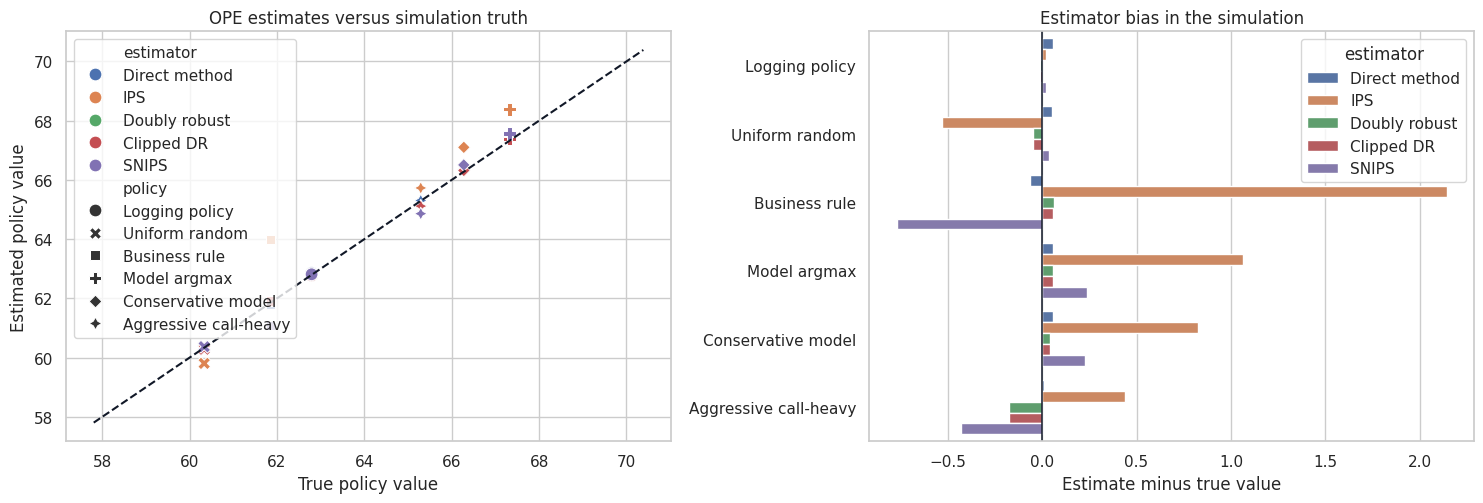

In [13]:
# Build the visualization for the estimates or diagnostics computed above.
fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))

selected_estimators = ["Direct method", "IPS", "SNIPS", "Doubly robust", "Clipped DR"]
plot_results = ope_results[ope_results["estimator"].isin(selected_estimators)].copy()

sns.scatterplot(
    data=plot_results,
    x="true_value",
    y="estimate",
    hue="estimator",
    style="policy",
    s=85,
    ax=axes[0],
)
min_value = min(plot_results["true_value"].min(), plot_results["estimate"].min()) - 2
max_value = max(plot_results["true_value"].max(), plot_results["estimate"].max()) + 2
axes[0].plot([min_value, max_value], [min_value, max_value], color="#111827", linestyle="--")
axes[0].set_title("OPE estimates versus simulation truth")
axes[0].set_xlabel("True policy value")
axes[0].set_ylabel("Estimated policy value")

bias_plot = plot_results.copy()
bias_plot["policy_estimator"] = bias_plot["policy"] + " | " + bias_plot["estimator"]
sns.barplot(
    data=bias_plot,
    y="policy",
    x="bias_vs_truth",
    hue="estimator",
    ax=axes[1],
)
axes[1].axvline(0, color="#111827", linewidth=1.1)
axes[1].set_title("Estimator bias in the simulation")
axes[1].set_xlabel("Estimate minus true value")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

The comparison shows the central OPE tradeoff:

- Direct method can have low variance but can be biased when the reward model is wrong.
- IPS is less model-dependent but can have high variance when target and logging policies disagree.
- SNIPS often stabilizes IPS but introduces small finite-sample bias.
- DR often performs well because it combines a reward model with propensity correction.
- Clipping reduces variance but adds bias.

No estimator dominates in every problem. The best estimator depends on overlap, reward-model quality, action-space size, and how far the target policy moves from the logging policy.

## 8. Inspecting Importance Weights

Importance weights are the mechanical heart of IPS and DR:

$$
w_i = \frac{\pi(A_i \mid X_i)}{\mu(A_i \mid X_i)}
$$

Large weights mean the target policy puts much more probability on the logged action than the logging policy did. Zero weights mean the logged action would not be chosen by the target policy.

Weight diagnostics are not optional. They tell us whether the logged data are informative for the proposed target policy.

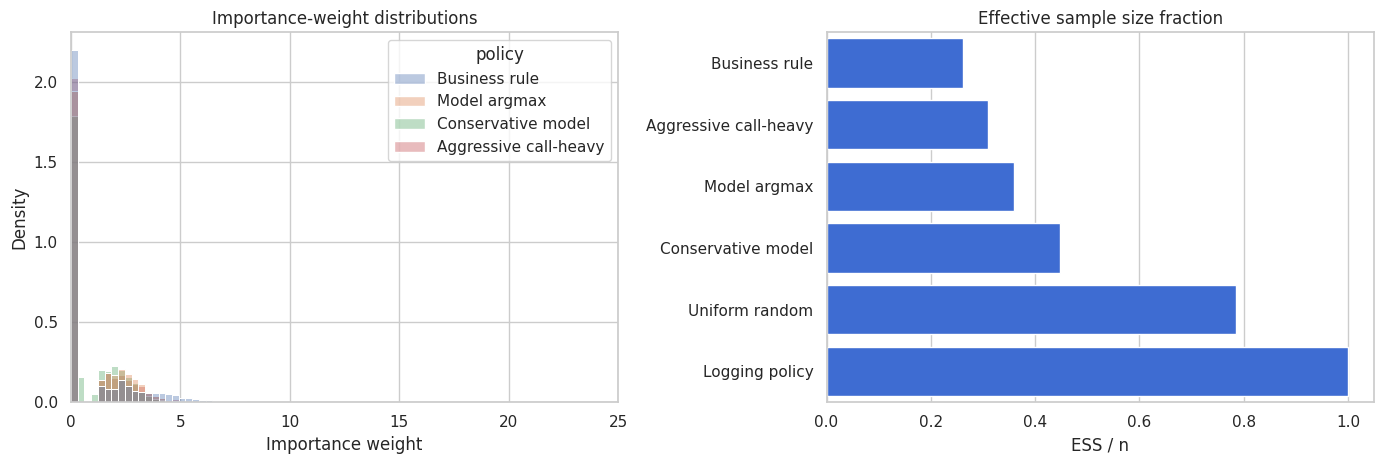

In [14]:
# Fit the models for this section and assemble the estimates used in the discussion.
weight_plot_rows = []
for policy_name, probs in target_policies.items():
    _, weights = evaluate_ope_estimators(eval_logs, probs, mu_hat_eval, clip=12.0)
    if policy_name in ["Business rule", "Model argmax", "Conservative model", "Aggressive call-heavy"]:
        sample_weights = pd.DataFrame({"policy": policy_name, "weight": weights})
        weight_plot_rows.append(sample_weights)

weight_plot = pd.concat(weight_plot_rows, ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

sns.histplot(
    data=weight_plot,
    x="weight",
    hue="policy",
    bins=45,
    common_norm=False,
    stat="density",
    alpha=0.38,
    ax=axes[0],
)
axes[0].set_xlim(0, 25)
axes[0].set_title("Importance-weight distributions")
axes[0].set_xlabel("Importance weight")

sns.barplot(
    data=weight_diagnostics,
    y="policy",
    x="ess_fraction",
    color="#2563eb",
    ax=axes[1],
)
axes[1].set_title("Effective sample size fraction")
axes[1].set_xlabel("ESS / n")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

The aggressive policy is the kind of policy that often makes OPE uncomfortable. It may be operationally attractive, but if historical logs rarely used the same actions in similar contexts, then the estimate depends on a thin slice of the data.

An OPE readout should not simply rank policies by point estimate. It should also report whether each estimate is supported by the logs.

## 9. Clipping Sensitivity

Clipping caps the largest importance weights:

$$
w_i^{clip} = \min(w_i, c)
$$

This reduces variance but changes the estimand. A large shift in the estimate across clipping thresholds is a warning that the evaluation is weight-sensitive.

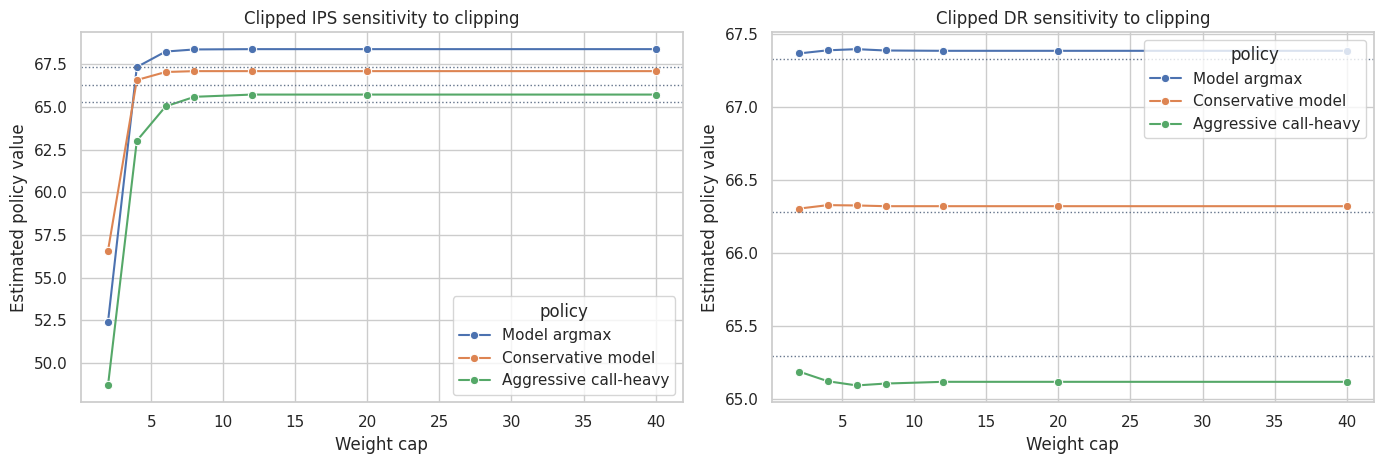

In [15]:
# Fit the models for this section and assemble the estimates used in the discussion.
clip_rows = []
clip_grid = [2, 4, 6, 8, 12, 20, 40]
for policy_name in ["Model argmax", "Conservative model", "Aggressive call-heavy"]:
    probs = target_policies[policy_name]
    truth = true_policy_value(eval_logs, probs)
    for clip_value in clip_grid:
        estimates, _ = evaluate_ope_estimators(eval_logs, probs, mu_hat_eval, clip=clip_value)
        subset = estimates[estimates["estimator"].isin(["Clipped IPS", "Clipped DR"])].copy()
        subset["clip"] = clip_value
        subset["policy"] = policy_name
        subset["true_value"] = truth
        clip_rows.append(subset)

clip_df = pd.concat(clip_rows, ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
for ax, estimator in zip(axes, ["Clipped IPS", "Clipped DR"]):
    sns.lineplot(
        data=clip_df[clip_df["estimator"] == estimator],
        x="clip",
        y="estimate",
        hue="policy",
        marker="o",
        ax=ax,
    )
    for policy_name in ["Model argmax", "Conservative model", "Aggressive call-heavy"]:
        truth = true_policy_value(eval_logs, target_policies[policy_name])
        ax.axhline(truth, color="#64748b", linestyle=":", linewidth=1)
    ax.set_title(f"{estimator} sensitivity to clipping")
    ax.set_xlabel("Weight cap")
    ax.set_ylabel("Estimated policy value")

plt.tight_layout()
plt.show()

Stable estimates across a reasonable clipping range are reassuring. Large movement means the offline estimate should be treated as exploratory before any launch decision.

logged data can evaluate a new policy only where the behavior policy created enough support for the actions being considered.

## 10. Known Versus Estimated Logging Propensities

Production OPE works best when the logging system records the exact action probabilities used at decision time.

If propensities are not logged, analysts may estimate them from historical data. That can be useful and adds another nuisance model with another source of bias. Worse, if the old policy was deterministic, the missing support cannot be repaired by estimating propensities after the fact.

Here we estimate the logging policy from the evaluation logs and compare OPE for one target policy using known versus estimated propensities.

In [16]:
# Fit the models for this section and assemble the estimates used in the discussion.
def crossfit_logging_propensities(frame, feature_cols, n_splits=5, seed=5713):
    """Build cross-fitted logging propensities quantities.
    
    Inputs:
    - `frame`: pandas DataFrame containing the rows for this function and the causal variables named by the other arguments.
    - `feature_cols`: list of pre-treatment covariate column names used as model features or effect modifiers.
    - `n_splits`: number of folds used for cross-fitting so rows are predicted out of sample.
    - `seed`: integer random seed that makes the simulation or model split reproducible.
    Returns: out-of-fold predictions or scores built without using each row to predict itself."""
    n = len(frame)
    prop_hat = np.zeros((n, N_ACTIONS))
    base_model = HistGradientBoostingClassifier(
        max_iter=180,
        learning_rate=0.045,
        min_samples_leaf=45,
        l2_regularization=0.03,
        random_state=seed,
    )
    kfold = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    for train_idx, test_idx in kfold.split(frame):
        train = frame.iloc[train_idx]
        test = frame.iloc[test_idx]
        model = clone(base_model)
        model.fit(train[feature_cols], train["action"])
        pred = model.predict_proba(test[feature_cols])
        full_pred = np.zeros((len(test), N_ACTIONS))
        for col_idx, action_id in enumerate(model.classes_):
            full_pred[:, int(action_id)] = pred[:, col_idx]
        prop_hat[test_idx, :] = np.clip(full_pred, 0.02, 0.98)
        prop_hat[test_idx, :] = prop_hat[test_idx, :] / prop_hat[test_idx, :].sum(axis=1, keepdims=True)
    return prop_hat


estimated_logging_probs = crossfit_logging_propensities(eval_logs, feature_cols)
known_logging_probs = eval_logs[logging_prob_cols].to_numpy()

propensity_compare = pd.DataFrame(
    {
        "diagnostic": [
            "Mean absolute propensity error",
            "Log loss using known logging probabilities",
            "Log loss using estimated logging probabilities",
        ],
        "value": [
            np.mean(np.abs(estimated_logging_probs - known_logging_probs)),
            log_loss(eval_logs["action"], known_logging_probs, labels=list(range(N_ACTIONS))),
            log_loss(eval_logs["action"], estimated_logging_probs, labels=list(range(N_ACTIONS))),
        ],
    }
)
display(propensity_compare)

,diagnostic,value
0,Mean absolute propensity error,0.091
1,Log loss using known logging probabilities,1.258
2,Log loss using estimated logging probabilities,1.384


The point is to connect the number to the decision it supports. The behavior policy is part of the evidence, so weights and support deserve as much attention as the value estimate.

In [17]:
# Fit the models for this section and assemble the estimates used in the discussion.
comparison_policy = "Conservative model"
known_estimates, known_weights = evaluate_ope_estimators(
    eval_logs,
    target_policies[comparison_policy],
    mu_hat_eval,
    logging_probs=known_logging_probs,
    clip=12.0,
)
estimated_estimates, estimated_weights = evaluate_ope_estimators(
    eval_logs,
    target_policies[comparison_policy],
    mu_hat_eval,
    logging_probs=estimated_logging_probs,
    clip=12.0,
)

known_estimates["propensity_source"] = "Known logged propensity"
estimated_estimates["propensity_source"] = "Estimated propensity model"
propensity_source_comparison = pd.concat([known_estimates, estimated_estimates], ignore_index=True)
propensity_source_comparison["true_value"] = true_policy_value(eval_logs, target_policies[comparison_policy])
propensity_source_comparison["bias_vs_truth"] = (
    propensity_source_comparison["estimate"] - propensity_source_comparison["true_value"]
)

display(
    propensity_source_comparison[
        ["propensity_source", "estimator", "estimate", "std_error", "true_value", "bias_vs_truth"]
    ]
)

,propensity_source,estimator,estimate,std_error,true_value,bias_vs_truth
0,Known logged propensity,Direct method,66.332,0.223,66.276,0.056
1,Known logged propensity,IPS,67.100,1.056,66.276,0.823
2,Known logged propensity,Clipped IPS,67.100,1.056,66.276,0.823
3,Known logged propensity,Doubly robust,66.319,0.272,66.276,0.043
4,Known logged propensity,Clipped DR,66.319,0.272,66.276,0.043
5,Known logged propensity,SNIPS,66.505,0.357,66.276,0.229
6,Estimated propensity model,Direct method,66.332,0.223,66.276,0.056
7,Estimated propensity model,IPS,80.279,1.547,66.276,14.003
8,Estimated propensity model,Clipped IPS,79.725,1.486,66.276,13.449
9,Estimated propensity model,Doubly robust,66.228,0.321,66.276,-0.048


The estimated propensity model is usable in this simulation. It is still inferior to having the true logged propensities. In real systems, logging propensities is a design requirement, not a reporting nicety.

## 11. Policy Contrast: Is the New Policy Better Than the Current One?

Often the real business question moves from absolute policy value to pairwise comparison.

> Is the proposed policy better than the current policy?

For a target policy $\pi$ and current policy $\mu$, estimate:

$$
\Delta = V(\pi)-V(\mu)
$$

The direct way is to estimate both values and subtract them. The uncertainty can be large because the two estimates are correlated. For a practical first pass, we can compute per-row DR contributions for both policies and take their difference.

In [18]:
# Fit the models for this section and assemble the estimates used in the discussion.
def dr_contribution(frame, target_probs, mu_hat, logging_probs=None):
    """Compute row-level doubly robust policy-value contributions.
    
    Inputs:
    - `frame`: pandas DataFrame containing the rows for this function and the causal variables named by the other arguments.
    - `target_probs`: target-policy action probabilities for each row in the logged dataset.
    - `mu_hat`: estimated reward matrix used as the outcome model in doubly robust evaluation.
    - `logging_probs`: behavior-policy probabilities for the actions observed in the logged data.
    Returns: a NumPy array of doubly robust scores for the target policy."""
    if logging_probs is None:
        logging_probs = frame[logging_prob_cols].to_numpy()
    action = frame["action"].to_numpy()
    reward = frame["reward"].to_numpy()
    n = len(frame)
    p_chosen = logging_probs[np.arange(n), action]
    q_chosen = target_probs[np.arange(n), action]
    weights = q_chosen / np.clip(p_chosen, 1e-6, None)
    dm_row = np.sum(target_probs * mu_hat, axis=1)
    residual = reward - mu_hat[np.arange(n), action]
    return dm_row + weights * residual


contrast_rows = []
logging_contrib = dr_contribution(eval_logs, target_policies["Logging policy"], mu_hat_eval)
for policy_name in ["Business rule", "Model argmax", "Conservative model", "Aggressive call-heavy"]:
    target_contrib = dr_contribution(eval_logs, target_policies[policy_name], mu_hat_eval)
    contrast = target_contrib - logging_contrib
    contrast_rows.append(
        {
            "policy": policy_name,
            "dr_gain_vs_logging": contrast.mean(),
            "std_error": contrast.std(ddof=1) / np.sqrt(len(contrast)),
            "ci_low": contrast.mean() - 1.96 * contrast.std(ddof=1) / np.sqrt(len(contrast)),
            "ci_high": contrast.mean() + 1.96 * contrast.std(ddof=1) / np.sqrt(len(contrast)),
            "true_gain_vs_logging": true_policy_value(eval_logs, target_policies[policy_name])
            - true_policy_value(eval_logs, target_policies["Logging policy"]),
        }
    )

contrast_table = pd.DataFrame(contrast_rows).sort_values("dr_gain_vs_logging", ascending=False)
display(contrast_table)

,policy,dr_gain_vs_logging,std_error,ci_low,ci_high,true_gain_vs_logging
1,Model argmax,4.605,0.144,4.322,4.887,4.533
2,Conservative model,3.539,0.119,3.306,3.772,3.484
3,Aggressive call-heavy,2.335,0.176,1.991,2.680,2.499
0,Business rule,-0.868,0.206,-1.272,-0.465,-0.942


Here the example becomes operational. Offline policy value is credible only when the log contains comparable actions in comparable contexts.

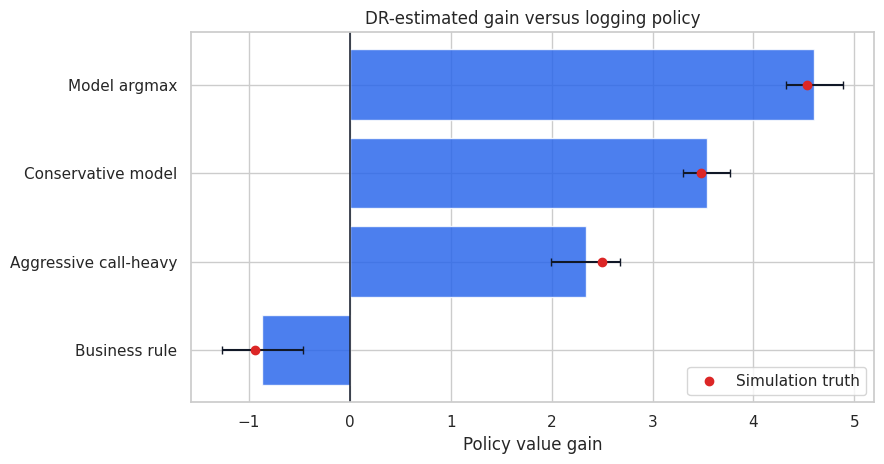

In [19]:
fig, ax = plt.subplots(figsize=(9, 4.8))
plot_contrast = contrast_table.sort_values("dr_gain_vs_logging")
ax.barh(plot_contrast["policy"], plot_contrast["dr_gain_vs_logging"], color="#2563eb", alpha=0.82)
ax.errorbar(
    x=plot_contrast["dr_gain_vs_logging"],
    y=np.arange(len(plot_contrast)),
    xerr=[
        plot_contrast["dr_gain_vs_logging"] - plot_contrast["ci_low"],
        plot_contrast["ci_high"] - plot_contrast["dr_gain_vs_logging"],
    ],
    fmt="none",
    ecolor="#111827",
    capsize=3,
)
ax.scatter(plot_contrast["true_gain_vs_logging"], np.arange(len(plot_contrast)), color="#dc2626", label="Simulation truth", zorder=5)
ax.axvline(0, color="#111827", linewidth=1.1)
ax.set_title("DR-estimated gain versus logging policy")
ax.set_xlabel("Policy value gain")
ax.legend()
plt.tight_layout()
plt.show()

This is the kind of table that belongs in an executive readout. It compares proposed policies to the current baseline, shows uncertainty, and keeps the support diagnostics nearby.

A high point estimate should still pass a support check before deployment. A policy with a slightly lower estimate but much better support may be the better next experiment.

## 12. Stress Test: What If the Target Policy Is Too Far Away?

OPE is strongest when the target policy is close enough to the logging policy that the logs contain relevant evidence.

If a proposed policy takes actions that the logging policy almost never took for similar contexts, then:

- IPS weights become extreme.
- SNIPS may look stable while estimating a support-limited quantity.
- Direct method relies heavily on extrapolation.
- DR inherits both reward-model risk and weight instability.

In practice, the right next step may be a small randomized exploration pilot, not a full launch.

In [20]:
support_summary = weight_diagnostics.merge(
    truth_table[["policy", "true_gain_vs_logging"]],
    on="policy",
    how="left",
)
support_summary["ope_risk_level"] = pd.cut(
    support_summary["ess_fraction"],
    bins=[-0.01, 0.10, 0.30, 0.60, 1.01],
    labels=["High", "Elevated", "Moderate", "Low"],
)

display(
    support_summary[
        [
            "policy",
            "true_gain_vs_logging",
            "ess_fraction",
            "max_weight",
            "share_weight_gt_10",
            "share_zero_weight",
            "ope_risk_level",
        ]
    ].sort_values("ess_fraction")
)

,policy,true_gain_vs_logging,ess_fraction,max_weight,share_weight_gt_10,share_zero_weight,ope_risk_level
0,Business rule,-0.942,0.262,13.851,0.001,0.677,Elevated
1,Aggressive call-heavy,2.499,0.309,10.549,0.000,0.623,Moderate
2,Model argmax,4.533,0.359,8.882,0.000,0.598,Moderate
3,Conservative model,3.484,0.448,7.882,0.000,0.000,Moderate
4,Uniform random,-2.459,0.785,4.620,0.000,0.000,Low
5,Logging policy,0.000,1.000,1.000,0.000,0.000,Low


## 13. Industry Readout Template

A professional OPE readout should be explicit about both value and reliability:

1. Decision: which target policy is being considered?
2. Logged data: time window, eligible population, action set, reward definition, and logging policy.
3. Identification: why historical action assignment can be treated as randomized conditional on context.
4. Propensities: whether exact propensities were logged or estimated after the fact.
5. Estimators: direct method, IPS/SNIPS, DR, and clipped variants.
6. Main result: estimated value and gain versus current policy.
7. Support diagnostics: ESS, max weights, zero-weight share, and action mix shift.
8. Sensitivity: clipping thresholds, reward-model choices, and target-policy stochasticity.
9. Recommendation: launch, reject, revise policy, or run an exploration pilot.

Good OPE is not just an estimator. It is a decision-control process for changing deployed systems safely.

In [21]:
# Assemble the summary table used to interpret the causal comparison.
recommended_policy = contrast_table.iloc[0]["policy"]
recommended_support = support_summary[support_summary["policy"] == recommended_policy].iloc[0]
recommended_contrast = contrast_table[contrast_table["policy"] == recommended_policy].iloc[0]

readout = pd.DataFrame(
    {
        "item": [
            "Top DR-estimated policy",
            "Estimated gain vs logging",
            "Approximate 95% CI",
            "Simulation true gain vs logging",
            "ESS fraction",
            "Maximum importance weight",
            "OPE risk level",
            "Recommended next step",
        ],
        "value": [
            recommended_policy,
            f"{recommended_contrast['dr_gain_vs_logging']:.2f}",
            f"[{recommended_contrast['ci_low']:.2f}, {recommended_contrast['ci_high']:.2f}]",
            f"{recommended_contrast['true_gain_vs_logging']:.2f}",
            f"{recommended_support['ess_fraction']:.2%}",
            f"{recommended_support['max_weight']:.1f}",
            str(recommended_support["ope_risk_level"]),
            "Use OPE as a screening result, then validate with a randomized pilot.",
        ],
    }
)
display(readout)

,item,value
0,Top DR-estimated policy,Model argmax
1,Estimated gain vs logging,4.60
2,Approximate 95% CI,"[4.32, 4.89]"
3,Simulation true gain vs logging,4.53
4,ESS fraction,35.91%
5,Maximum importance weight,8.9
6,OPE risk level,Moderate
7,Recommended next step,"Use OPE as a screening result, then validate w..."


## Key Takeaways

- OPE estimates the value of a target policy using data logged under another policy.
- Partial feedback is the central problem: only the chosen action's reward is observed.
- IPS corrects the action-distribution mismatch with importance weights.
- SNIPS often reduces variance but can introduce finite-sample bias.
- Direct method depends heavily on reward-model quality.
- Doubly robust estimation combines reward modeling with importance-weighted residual correction.
- Weight diagnostics are central. Low ESS and large weights mean the logged data provide weak support.
- Exact logged propensities are a production requirement for reliable OPE.
- Clipping, shrinkage, and stochastic target policies can improve stability, but they change the bias-variance tradeoff.
- OPE should usually screen policies for experimentation, not replace final validation for high-stakes decisions.

## References

Dudík, M., Erhan, D., Langford, J., & Li, L. (2014). Doubly robust policy evaluation and optimization. *Statistical Science, 29*(4), 485-511. [https://doi.org/10.1214/14-sts500](https://doi.org/10.1214/14-sts500)

Horvitz, D. G., & Thompson, D. J. (1952). A generalization of sampling without replacement from a finite universe. *Journal of the American Statistical Association, 47*(260), 663-685. [https://doi.org/10.1080/01621459.1952.10483446](https://doi.org/10.1080/01621459.1952.10483446)

Saito, Y., & Joachims, T. (2022). Off-policy evaluation for large action spaces via embeddings. arXiv. [https://doi.org/10.48550/arxiv.2202.06317](https://doi.org/10.48550/arxiv.2202.06317)

Su, Y., Dimakopoulou, M., Krishnamurthy, A., & Dudík, M. (2019). Doubly robust off-policy evaluation with shrinkage. arXiv. [https://doi.org/10.48550/arxiv.1907.09623](https://doi.org/10.48550/arxiv.1907.09623)

Zhan, R., Hadad, V., Hirshberg, D. A., & Athey, S. (2021). Off-policy evaluation via adaptive weighting with data from contextual bandits. arXiv. [https://doi.org/10.48550/arxiv.2106.02029](https://doi.org/10.48550/arxiv.2106.02029)